In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }; .cell {width:100%} ; .code_cell{width:100%}</style>"))

In [2]:
%matplotlib inline
import matplotlib
import os
import glob
import datetime
import traceback
from obspy.core import read, UTCDateTime
from obspy import UTCDateTime, Stream, read
from obspy.geodetics.base import gps2dist_azimuth
from obspy.core.util import AttribDict
import matplotlib
import matplotlib as mpl
new_style = {'grid': False}
mpl.rc('axes', **new_style)
# mpl.rcParams['font.family'] = 'Helvetica'
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_style("whitegrid")
sns.set_palette("dark")
# import tqdm

from obspy.signal.cross_correlation import xcorr_pick_correction
import warnings
from collections import defaultdict
from obspy.signal.cross_correlation import correlate,xcorr_max

from scipy.cluster.hierarchy import dendrogram, set_link_color_palette, linkage
from scipy.spatial.distance import squareform
import matplotlib.gridspec as gridspec
from matplotlib.colors import rgb2hex, colorConverter


In [3]:
station = "GRW0"
channel = "BHZ"

traces = []
for typ in ["VTB", "MP", "gugu_long", "gugu_short", "NN", "ND"]:
    for file in glob.glob("events/%s/*.mseed" % typ):
     tr = read(file).select(station=station,channel=channel)[0]
     tr.stats.event_type = typ
     traces.append(tr)
st = Stream(traces=traces)

In [4]:
st

103 Trace(s) in Stream:

XM.GRW0..BHZ | 1998-07-05T06:34:07.978000Z - 1998-07-05T06:34:32.978000Z | 40.0 Hz, 1001 samples
...
(101 other traces)
...
XM.GRW0..BHZ | 1998-07-02T03:42:26.803000Z - 1998-07-02T03:42:51.803000Z | 40.0 Hz, 1001 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

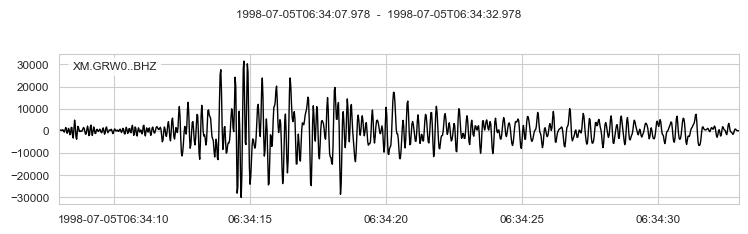

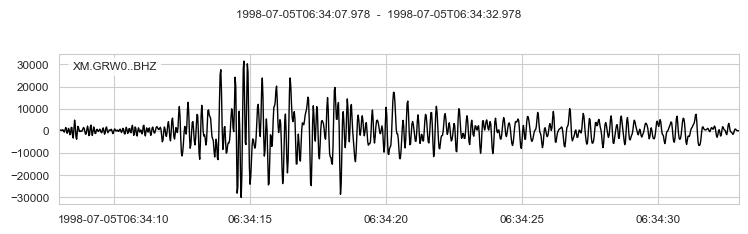

In [5]:
freqlow=1.0
freqhigh=10.0

st2 = st.copy()
# st2.sort()
st2.detrend("demean")
st2.taper(None, max_length=0.5)
st2.filter("bandpass", freqmin=freqlow, freqmax=freqhigh, corners=8, zerophase=True)
# st2.resample(100.0)
# st2.sort()
# st2.filter("bandpass", freqmin=8.0, freqmax=30.0, corners=8) #.plot(equal_scale=False, size=(1200, 1200))
st2[0].plot(automerge=False)

In [6]:
st2

103 Trace(s) in Stream:

XM.GRW0..BHZ | 1998-07-05T06:34:07.978000Z - 1998-07-05T06:34:32.978000Z | 40.0 Hz, 1001 samples
...
(101 other traces)
...
XM.GRW0..BHZ | 1998-07-02T03:42:26.803000Z - 1998-07-02T03:42:51.803000Z | 40.0 Hz, 1001 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

In [7]:
similarity = np.eye(len(st2))
dts = np.zeros((len(st2),len(st2)))

In [8]:
picks = []
relpicks = []
for tr in st2:
    t = tr.stats.starttime + 5.0
    picks.append(t)

In [9]:
before= 3
after = 20
freqmin = freqlow
freqmax = freqhigh
cc_maxlag = 5
phase = "*"
taxis = (np.arange(st2[0].stats.npts) * st2[0].stats.delta)
sel = np.where((taxis>=before) & (taxis<=after))[0]

In [10]:


for i, pick1 in enumerate(picks):
    tr1 = st2[i].copy()
    print(i, "vs all")
    for j, pick2 in enumerate(picks):
        if j <= i:
            continue
        
        tr2 = st2[j].copy()

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
#                 dt, coeff = xcorr_pick_correction(pick1, tr1, pick2, tr2, t_before=before, t_after=after, 
#                                                   cc_maxlag=cc_maxlag, filter=None,
#                                                   filter="bandpass", filter_options={"freqmin":freqmin, "freqmax":freqmax,"corners":8},
#                                                   plot=False)
                cc = correlate(tr1.data[sel], tr2.data[sel], 0)
                dt, coeff = xcorr_max(cc)    
            except:
                traceback.print_exc()
                coeff = 0
                continue
            similarity[i,j] = coeff
            similarity[j,i] = coeff
            dts[i,j] = dt
            dts[j,i] = dt

0 vs all
1 vs all
2 vs all
3 vs all
4 vs all
5 vs all
6 vs all
7 vs all
8 vs all
9 vs all
10 vs all
11 vs all
12 vs all
13 vs all
14 vs all
15 vs all
16 vs all
17 vs all
18 vs all
19 vs all
20 vs all
21 vs all
22 vs all
23 vs all
24 vs all
25 vs all
26 vs all
27 vs all
28 vs all
29 vs all
30 vs all
31 vs all
32 vs all
33 vs all
34 vs all
35 vs all
36 vs all
37 vs all
38 vs all
39 vs all
40 vs all
41 vs all
42 vs all
43 vs all
44 vs all
45 vs all
46 vs all
47 vs all
48 vs all
49 vs all
50 vs all
51 vs all
52 vs all
53 vs all
54 vs all
55 vs all
56 vs all
57 vs all
58 vs all
59 vs all
60 vs all
61 vs all
62 vs all
63 vs all
64 vs all
65 vs all
66 vs all
67 vs all
68 vs all
69 vs all
70 vs all
71 vs all
72 vs all
73 vs all
74 vs all
75 vs all
76 vs all
77 vs all
78 vs all
79 vs all
80 vs all
81 vs all
82 vs all
83 vs all
84 vs all
85 vs all
86 vs all
87 vs all
88 vs all
89 vs all
90 vs all
91 vs all
92 vs all
93 vs all
94 vs all
95 vs all
96 vs all
97 vs all
98 vs all
99 vs all
100 vs all

In [11]:
similarity = abs(similarity)

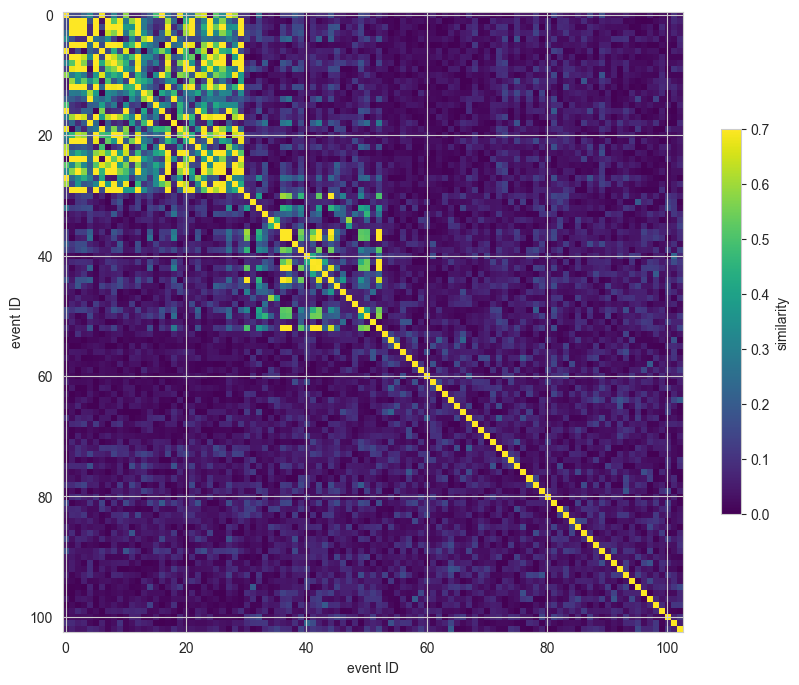

In [12]:
plt.figure(figsize=(10,10))
plt.imshow(similarity,interpolation="none", cmap="viridis", vmin=-0., vmax=0.7, )
plt.xlabel("event ID")
plt.ylabel("event ID")
cb = plt.colorbar(shrink=0.5)
cb.ax.set_ylabel('similarity')

# plt.savefig('matrix %s.%s %s.png'%(sta,comp, phase), dpi=300)
plt.show()

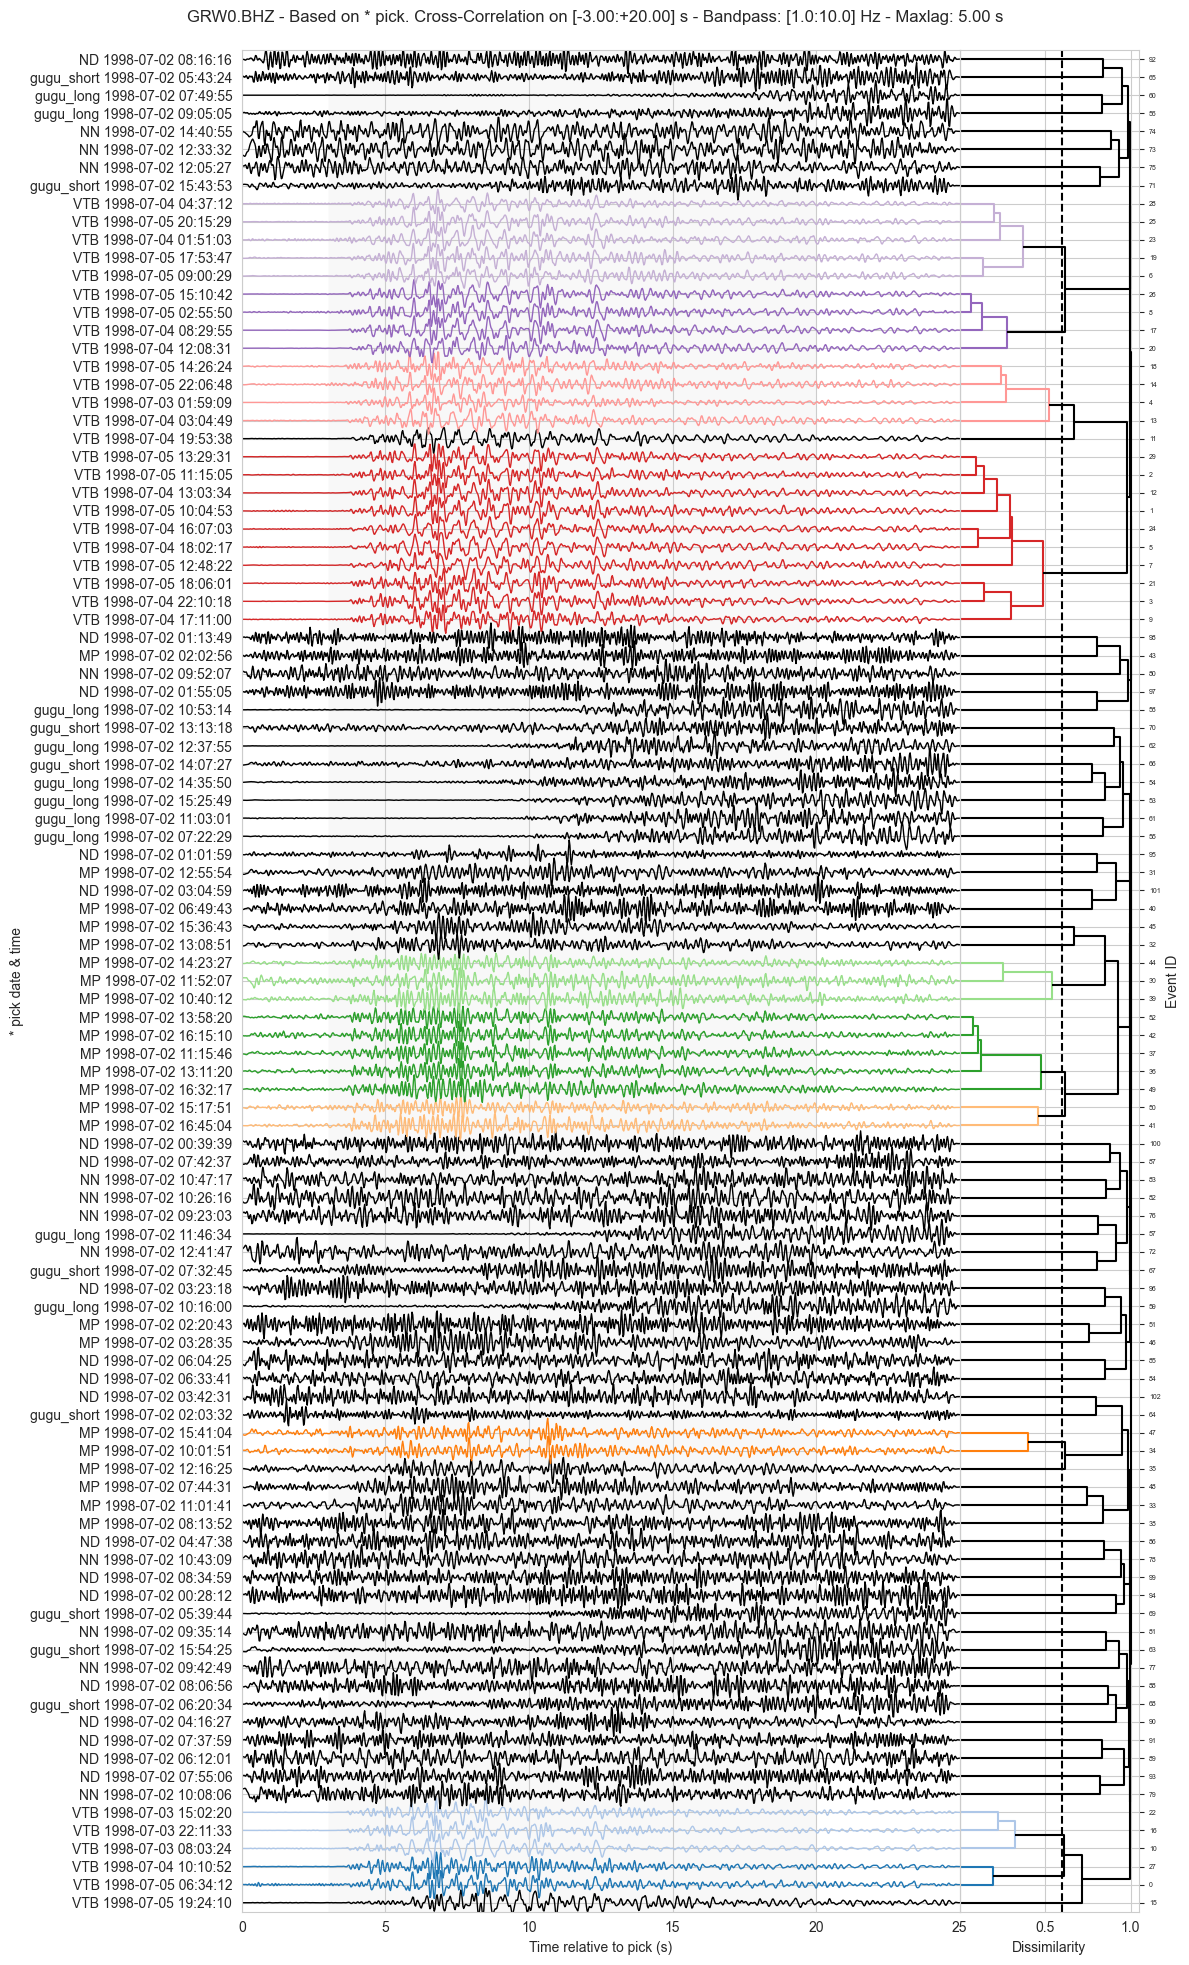

In [13]:
sns.set_palette(sns.color_palette("tab20", 20))
palette = sns.color_palette()

set_link_color_palette(list(map(rgb2hex, palette)))

def get_cluster_classes(den, label='ivl'):
    cluster_idxs = defaultdict(str)
    for c, pi in zip(den['color_list'], den['icoord']):
        for leg in pi[1:3]:
            i = (leg - 5.0) / 10.0
            if abs(i - int(i)) < 1e-5:
#                 cluster_idxs[c].append(int(i))
                cluster_idxs[den[label][int(i)]] =  c
    return cluster_idxs

fig = plt.figure(figsize=(12,20))

gs = gridspec.GridSpec(1, 2,
                       width_ratios=[4,1],
                       )



linkage_method = "complete"
dissimilarity_threshold = 0.6

distance = squareform(1-similarity)
linkage_matrix = linkage(distance, method=linkage_method)

plt.subplot(gs[1])
D = dendrogram(linkage_matrix, color_threshold=dissimilarity_threshold, orientation="right",above_threshold_color='k')
plt.gca().yaxis.tick_right()
plt.gca().yaxis.set_label_position("right")
plt.axvline(dissimilarity_threshold, c='k',ls="--")
plt.xlabel("Dissimilarity")
plt.ylabel("Event ID")
plt.setp(plt.gca().get_xticklabels()[0], visible=False)    

plt.subplot(gs[0])

colors = get_cluster_classes(D)

previous = "w"
previous_idx = 0
clusters = {}
clusters_shifts = {}
cluster_color = {}
cluster_id = 0

for i, index in enumerate(D['ivl']):
    tri = st2[int(index)]
#     taxis = np.arange(tri.stats.npts)*tri.stats.delta - Pcorr
    tri.normalize()
    try:
        c = colors[str(int(index))]
    except:
        c='k'
        pass
    
    
    if c != previous:
        cluster_id += 1
        previous = c
        previous_idx = int(index)
        shift = 0
        shift_to_first = 0
    else:
        shift = dts[previous_idx, int(index)]
        shift_to_first = dts[0, int(index)]
    
#     max_diff = relpicks[int(index)] - relpicks[previous_idx]
    
    if cluster_id not in clusters:
        clusters[cluster_id] = []
        clusters_shifts[cluster_id] = []
        cluster_color[cluster_id] = c

    clusters[cluster_id].append(int(index))
    clusters_shifts[cluster_id].append(shift)

    plt.plot(taxis+shift-shift_to_first, tri.data*0.8+i, lw=1,c=c)
    

plt.xlabel("Time relative to pick (s)")
plt.ylim(-.5,i+.5)


plt.axvspan(before, after, zorder=-10, alpha=0.1, facecolor='silver')
indexes = [int(_) for _ in D['ivl']]
dlabel = []
for i in np.array(indexes):
    d = np.array(picks)[i]
    et = st2[i].stats.event_type
    label = "%s " % et + d.strftime('%Y-%m-%d %H:%M:%S')
    dlabel.append(label)
# dlabel = [d.strftime('%Y-%m-%d %H:%M:%S')+" %" % t.stats.event_type for d,t in zip(np.array(picks)[np.array(indexes)],st2[np.array(indexes)])]

# xEvents = picks[np.array(indexes)]
yEvents = [np.ptp(st[int(d)].data) for d in D['ivl']]
cEvents = [colors[str(int(d))] for d in D['ivl']]

plt.yticks(np.arange(len(D['ivl'])), dlabel)
plt.ylabel("%s pick date & time"%phase)

plt.suptitle("%s.%s - Based on %s pick. Cross-Correlation on [-%.2f:+%.2f] s - Bandpass: [%.1f:%.1f] Hz - Maxlag: %.2f s" % 
             (station, channel, phase, before, after, freqmin, freqmax, cc_maxlag))
plt.tight_layout()
plt.subplots_adjust(top=0.96, wspace=0)

plt.setp(plt.gca().get_xticklabels()[-1], visible=False)    

plt.xlim(0,25)

plt.savefig('similarity %s.%s.png'%(station,channel), dpi=300)
plt.show()
